# Segment 2: Activation Maximization

*Contributed by Joyce Jiang*

Activation maximization works by directly optimizing an input image to increase the activation of a chosen internal unit while keeping the model fixed.

In this implementation, we target individual channels in the mixed4a layer of InceptionV1 and perform gradient ascent on the input image using the Lucent library.

The resulting images reveal the visual patterns that most strongly drive each neuron under a specific optimization setup, providing intuition about internal feature representations rather than definitive semantic meanings.


In [ ]:
!pip install git+https://github.com/greentfrapp/lucent.git

In [ ]:
# Imports
import torch
import torchvision.models as models
import matplotlib.pyplot as plt

from lucent.optvis import render, param, objectives
from lucent.modelzoo import inceptionv1

device = "cuda" if torch.cuda.is_available() else "cpu"

# load inceptionv1 from lucent
model = inceptionv1(pretrained=True).to(device)
model.eval()

# print(model)

In [22]:
def maximize_neuron(layer="mixed4a", channel=0, steps=128):
    """
    Perform activation maximization for a single neuron (channel)
    in a specified layer using Lucent.

    This function synthesizes an input image that maximally activates
    a chosen internal unit of a pretrained InceptionV1 model.
    """

    # 1. Define the optimization objective
    #    Here, we maximize the mean activation of one channel in the target layer.
    #    This specifies *what internal response* we want to amplify.
    obj = objectives.channel(layer, channel)

    # 2. Define the image parameterization
    #    Lucent represents the input image as a set of optimizable parameters.
    #    Wrapping param.image in a lambda makes it compatible with Lucent's rendering pipeline across different versions.
    param_f = lambda: param.image(224)

    # 3. Specify optimization length
    #    Lucent uses 'thresholds' to control how many optimization steps are run.
    #    A single value [steps] indicates one continuous optimization phase.
    thresholds = [steps]

    # 4. Run activation maximization
    #    This performs gradient ascent on the input image to increase
    #    the target neuron's activation while keeping model weights fixed.
    images = render.render_vis(
        model,        # pretrained InceptionV1 model
        obj,          # optimization objective
        param_f,      # image parameterization (callable)
        None,         # optimizer (use Lucent's default)
        None,         # transforms (none applied)
        thresholds,   # number of optimization steps
        False,        # verbose output
        None,         # preprocessing function
        True,         # show progress bar
        False         # do not display intermediate images
    )

    # Lucent returns shape (1, H, W, 3); remove batch dim
    return images[0].squeeze(0)

# Verify the activation maximization function with one neuron
# img = maximize_neuron(layer="mixed4a", channel=0, steps=128)
# plt.imshow(img)
# plt.axis("off")
# plt.show()

100%|██████████| 128/128 [00:04<00:00, 30.68it/s]


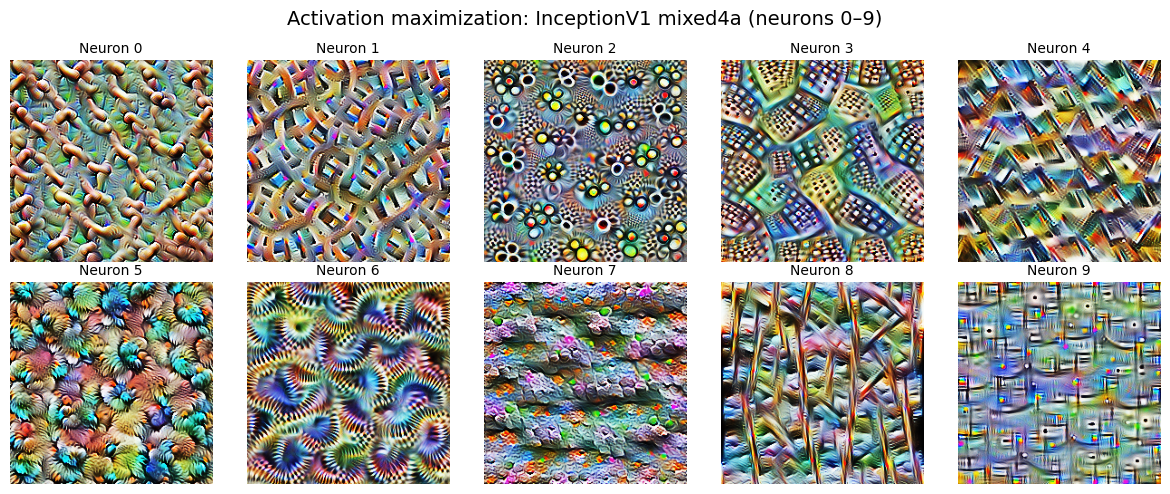

In [24]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ch, ax in enumerate(axes.flat):
    img = maximize_neuron(layer="mixed4a", channel=ch, steps=128)
    ax.imshow(img)
    ax.set_title(f"Neuron {ch}", fontsize=10)
    ax.axis("off")

plt.suptitle("Activation maximization: InceptionV1 mixed4a (neurons 0–9)", fontsize=14)
plt.tight_layout()
plt.show()
